# 7 -- Modelo LSTM del pipeline hibrido — Dataset FDIC RIS

Con los embeddings relacionales e_rel del bloque de desarrollo ya extraidos y validados, el siguiente paso es entrenar el componente LSTM del modelo estrella siguiendo el mismo protocolo que en el Baseline, con una unica diferencia sustancial en la entrada: en lugar de las secuencias de e_tab de dimension 192, se construyen secuencias de e_rel de dimension 32.
El procedimiento es identico en estructura. Se parte de los 125.575 pares (CERT, period) del bloque de desarrollo, se asignan indices de periodo, se fija la misma frontera train/val de N_VAL_PERIODS=8 (2020Q1 a 2021Q4) que demostro empiricamente dejar positivos suficientes en validacion para un early stopping estable, y se construyen ventanas deslizantes de longitud T=4 con stride=1 y consecutividad estricta por CERT. El dataset, el DataLoader y el bucle de entrenamiento con early stopping sobre AUC-PR son los mismos que en el Baseline.
Los cambios respecto al Baseline son tres y estan acotados. Primero, la fuente de embeddings pasa de emb_dev (e_tab, 192 dims) a erel_dev (e_rel, 32 dims), con la misma estructura de columnas META + dims flotantes. Segundo, el parametro d_in del LSTMBaseline pasa de 192 a 32. Tercero, pos_weight se recalcula sobre las secuencias construidas desde e_rel, aunque al compartir exactamente la misma poblacion de pares (CERT, period) y la misma frontera train/val, el valor resultante deberia ser identico o negligiblemente distinto al del Baseline.
El resto del pipeline, arquitectura LSTM con hidden_dim=32, optimizador AdamW, scheduler ReduceLROnPlateau, clip de gradiente, y criterio BCEWithLogitsLoss con pw_factor, se mantiene sin cambios para que la comparacion entre Baseline y modelo estrella sea atribuible exclusivamente a la representacion de entrada y no a diferencias de entrenamiento.

In [11]:
# ============================================================================
# BLOQUE 1 — CARGA Y VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO RELACIONALES (e_rel)
# ============================================================================
#
# Modelo: LSTM (solo datos numéricos/relaciones tabulares vía T-GCN)
#
# Objetivo de este bloque: cargar erel_desarrollo.parquet, verificar
# su consistencia con el panel etiquetado original, y dejar un DataFrame
# único (emb_dev_rel_labeled) listo para la construcción de secuencias del
# Bloque 2.
#
# NO se toca en ningún momento el bloque de evaluación (2022Q1-2025Q4):
# permanece reservado hasta la evaluación final del modelo ya entrenado.
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ----------- 1.0 REPRODUCIBILIDAD -----------
SEED = 42
np.random.seed(SEED)

# ----------- 1.1 RUTAS -----------
DATA_ROOT = Path("D:/financial_risk_data")
EMBEDDINGS_ROOT = DATA_ROOT / "embeddings"

EMB_DEV_PATH = EMBEDDINGS_ROOT / "emb_rel_dev/erel_desarrollo.parquet"
PANEL_LABEL_PATH = DATA_ROOT / "processed" / "panel_tabular_labeled.parquet"


# Carga de ambos embeddings y del panel de etiquetas para google colab
emb_dev_rel    = pd.read_parquet("D:/financial_risk_data/embeddings/emb_rel_dev/erel_desarrollo.parquet")
panel_label = pd.read_parquet("D:/financial_risk_data/processed/panel_tabular_labeled.parquet")

VERBOSE = True

# ----------- 1.2 CARGA -----------
emb_dev_rel = pd.read_parquet(EMB_DEV_PATH)
panel_label = pd.read_parquet(PANEL_LABEL_PATH)

if VERBOSE:
    print(f"emb_dev_rel shape     : {emb_dev_rel.shape}")
    print(f"panel_label shape : {panel_label.shape}")

# ----------- 1.3 NORMALIZACIÓN DE TIPOS -----------
for df in [emb_dev_rel, panel_label]:
    df["CERT"] = df["CERT"].astype(str)
    df["period"] = df["period"].astype(str)

# ----------- 1.4 IDENTIFICAR COLUMNAS DE EMBEDDING -----------
META_DEV = ["CERT", "period", "y"]
cols_emb = [c for c in emb_dev_rel.columns if c not in META_DEV]

assert len(cols_emb) == 32, (
    f"Se esperaban 32 dimensiones de embedding (espacio latente de "
    f"T-GCN), se encontraron {len(cols_emb)}."
)

# ----------- 1.5 UNIR ETIQUETA failed DESDE panel_tabular_labeled -----------
# Se usa la MISMA fuente de etiqueta para garantizar comparabilidad histórica de los números.
# how='left' + fillna(0): un CERT/period sin entrada en panel_label se
# asume no-quiebra (consistente con el procesamiento ya usado en el
# documento de extracción de TabPFN: panel['failed'].fillna(0).astype(int)).

emb_dev_rel_labeled = emb_dev_rel.merge(
    panel_label[["CERT", "period", "failed"]],
    on=["CERT", "period"],
    how="left",
)
n_sin_etiqueta = emb_dev_rel_labeled["failed"].isna().sum()
emb_dev_rel_labeled["failed"] = emb_dev_rel_labeled["failed"].fillna(0).astype(int)

# ----------- 1.6 VERIFICACIÓN DE INVARIANTES -----------
n_obs = len(emb_dev_rel_labeled)
n_pos = int(emb_dev_rel_labeled["failed"].sum())
n_nan_emb = emb_dev_rel_labeled[cols_emb].isna().sum().sum()
n_periodos = emb_dev_rel_labeled["period"].nunique()
periodos_sorted = sorted(emb_dev_rel_labeled["period"].unique())

assert n_nan_emb == 0, f"NaN en columnas de embedding: {n_nan_emb}"
assert n_periodos == 23, (
    f"Periodos esperados: 23 (2016Q2→2021Q4, 2016Q1 omitido por falta de "
    f"contexto TabPFN), obtenidos: {n_periodos}"
)
assert periodos_sorted[0] == "2016Q2", f"Primer periodo inesperado: {periodos_sorted[0]}"
assert periodos_sorted[-1] == "2021Q4", f"Último periodo inesperado: {periodos_sorted[-1]}"

# Verificación cruzada: el nº de positivos debe ser compatible con los 70
# positivos documentados para el bloque desarrollo completo (2016Q1-2021Q4,
# 24 trimestres). Al faltar 2016Q1 en el embedding, se espera un nº de
# positivos ligeramente MENOR o IGUAL a 70 (los de 2016Q1 no tienen
# embedding y por tanto no pueden entrar en ninguna secuencia).
if VERBOSE:
    print("\n" + "=" * 60)
    print("BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_rel)")
    print("=" * 60)
    print(f"Observaciones totales        : {n_obs:,}")
    print(f"Positivos (failed=1)         : {n_pos}")
    print(f"Tasa de positivos            : {n_pos/n_obs:.6f}")
    print(f"Filas sin match en panel_label (asumidas failed=0) : {n_sin_etiqueta}")
    print(f"Dimensión de embedding        : {len(cols_emb)}")
    print(f"NaN en embeddings             : {n_nan_emb}")
    print(f"Periodos                      : {n_periodos}  ({periodos_sorted[0]} → {periodos_sorted[-1]})")
    print(f"Entidades (CERT) únicas       : {emb_dev_rel_labeled['CERT'].nunique():,}")
    print("=" * 60)


emb_dev_rel shape     : (125575, 35)
panel_label shape : (206129, 3)

BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_rel)
Observaciones totales        : 125,575
Positivos (failed=1)         : 63
Tasa de positivos            : 0.000502
Filas sin match en panel_label (asumidas failed=0) : 0
Dimensión de embedding        : 32
NaN en embeddings             : 0
Periodos                      : 23  (2016Q2 → 2021Q4)
Entidades (CERT) únicas       : 6,176


In [12]:
assert (emb_dev_rel_labeled["y"].astype(int) == emb_dev_rel_labeled["failed"]).all(), \
    "Discrepancia entre columna 'y' del T-GCN y 'failed' de panel_label"
print("Verificacion y == failed: OK")

Verificacion y == failed: OK


Pasamos al Bloque 2. El codigo es una traslacion directa del Baseline cambiando tres cosas: la variable de entrada es emb_dev_labeled construida desde e_rel, cols_emb tiene 32 dimensiones en vez de 192, y d_in=32 en la instanciacion del modelo. Las funciones del modulo temporal_sequences y el resto del pipeline se invocan identicos.
Lo unico que hay que recalcular desde cero es pos_weight_raw, porque aunque el numero de positivos en secuencias de train deberia ser muy similar al Baseline, el numero total de secuencias validas puede diferir ligeramente si algun CERT tiene continuidad en e_tab pero no en e_rel o viceversa, lo que cambiaria el denominador del ratio.
La frontera N_VAL_PERIODS=8 se mantiene por la misma justificacion empirica que en el Baseline: es la frontera minima que garantiza positivos suficientes en validacion para que el early stopping sobre AUC-PR sea estable.
Pasa el output del bloque de verificacion de secuencias y del diagnostico de batches cuando los tengas, para confirmar que los numeros de positivos en train y val cuadran con lo esperado antes de instanciar el modelo.

In [ ]:
# ============================================================================
# BLOQUE 2   — CONSTRUCCIÓN DE SECUENCIAS TEMPORALES (target supervisado)
# ============================================================================
#
# Ventana deslizante T=4, stride=1, consecutividad estricta

# Diferencia respecto al diseño anterior: `failed` en period_end es ahora
# el TARGET de la función de pérdida (BCEWithLogitsLoss), no un metadato
# informativo. La frontera train/val se fija en N_VAL_PERIODS=8
# (2020Q1→2021Q4), justificada empíricamente en el Bloque 2a: deja 7
# positivos en val frente a 2 con la frontera genérica anterior (N=4),
# dando una señal de validación más estable para early stopping vía AUC-PR.
# ============================================================================

import importlib
import sys
import os


# Retroceder un nivel desde 'notebooks' para llegar a la raíz del proyecto
proyecto_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))

if proyecto_raiz not in sys.path:
    sys.path.insert(0, proyecto_raiz)


if "src.utils.temporal_sequences" in sys.modules:
    importlib.reload(sys.modules["src.utils.temporal_sequences"])

from src.utils.temporal_sequences import (
    asignar_period_idx, calcular_frontera_train_val,
    build_sequences_supervised, verificar_secuencias_supervisadas,
    calcular_pos_weight_raw, SupervisedSequenceDataset,
)

WINDOW_LENGTH = 4
STRIDE = 1
N_VAL_PERIODS = 8

emb_dev_rel_labeled, period_to_idx, all_periods_sorted = asignar_period_idx(emb_dev_rel_labeled)
train_periods, val_periods = calcular_frontera_train_val(all_periods_sorted, N_VAL_PERIODS)

sequences_train, sequences_val = build_sequences_supervised(
    df=emb_dev_rel_labeled, cols_emb=cols_emb,
    window_len=WINDOW_LENGTH, stride=STRIDE, val_periods=val_periods,
)

verificar_secuencias_supervisadas(sequences_train, sequences_val, val_periods, WINDOW_LENGTH, cols_emb)
pos_weight_raw = calcular_pos_weight_raw(sequences_train)



Raíz del proyecto añadida: c:\dev\tfm-financial_risk
Frontera train/val (N_VAL_PERIODS=8):
  Train period_end hasta : 2019Q4
  Val period_end desde   : 2020Q1
  Periodos en val        : ['2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']

Ventanas descartadas por huecos: 0

BLOQUE — VERIFICACIÓN DE SECUENCIAS (target supervisado)
Secuencias train         : 66,922
  Positivos en train     : 34  (tasa: 0.000508)
Secuencias val           : 40,355
  Positivos en val       : 7  (tasa: 0.000173)
Total secuencias         : 107,277
Shape por secuencia      : (4, 32)

pos_weight (ratio bruto neg/pos en train): 1967.29


In [19]:
from torch.utils.data import DataLoader
import torch

# ========== DATALOADER CONSTRUCTION ==========

# Datasets ya construidos en el notebook anterior
dataset_train = SupervisedSequenceDataset(sequences_train)
dataset_val = SupervisedSequenceDataset(sequences_val)

# Hiperparámetros de DataLoader
BATCH_SIZE = 256  # Justificado: E[pos/batch]=0.13, pos_weight=1966 compensa magnitud
SHUFFLE_TRAIN = True  # Shuffle simple, no WeightedRandomSampler
PIN_MEMORY = torch.cuda.is_available() # GPU pinning si disponible
NUM_WORKERS = 0  # Cambiar a 2-4 en producción si data loading es bottleneck


dataloader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE_TRAIN,
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False  # Mantener último batch aunque sea < 256
)

dataloader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,  # Validación sin permutación
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False
)

# ========== DIAGNÓSTICO DE BATCHES ==========

print("=" * 70)
print("DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES")
print("=" * 70)

# Inspeccionar distribución de positivos en el primer epoch
pos_per_batch_train = []
for batch_idx, batch in enumerate(dataloader_train):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_train.append(n_pos_batch)

pos_per_batch_train = torch.tensor(pos_per_batch_train, dtype=torch.float32)

print(f"\nTRAIN (shuffle=True, batch_size={BATCH_SIZE}):")
print(f"  Total batches            : {len(pos_per_batch_train)}")
print(f"  Batches sin positivos    : {(pos_per_batch_train == 0).sum().item()} "
      f"({100*(pos_per_batch_train == 0).sum().item()/len(pos_per_batch_train):.1f}%)")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_train > 0).sum().item()} "
      f"({100*(pos_per_batch_train > 0).sum().item()/len(pos_per_batch_train):.1f}%)")
print(f"  E[positivos/batch]       : {pos_per_batch_train.mean().item():.3f}")
print(f"  σ[positivos/batch]       : {pos_per_batch_train.std().item():.3f}")
print(f"  Max positivos en batch   : {pos_per_batch_train.max().item():.0f}")

print(f"\nVAL (shuffle=False, batch_size={BATCH_SIZE}):")
pos_per_batch_val = []
for batch_idx, batch in enumerate(dataloader_val):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_val.append(n_pos_batch)

pos_per_batch_val = torch.tensor(pos_per_batch_val, dtype=torch.float32)
print(f"  Total batches            : {len(pos_per_batch_val)}")
print(f"  Batches sin positivos    : {(pos_per_batch_val == 0).sum().item()}")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_val > 0).sum().item()}")
print(f"  E[positivos/batch]       : {pos_per_batch_val.mean().item():.3f}")

print("\n" + "=" * 70)
print(f"pos_weight (a usar en BCEWithLogitsLoss) : {pos_weight_raw:.2f}")
print(f"Justificación: cada positivo pesa {pos_weight_raw:.0f}x un negativo")
print("=" * 70)

DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES

TRAIN (shuffle=True, batch_size=256):
  Total batches            : 262
  Batches sin positivos    : 229 (87.4%)
  Batches con ≥1 positivo  : 33 (12.6%)
  E[positivos/batch]       : 0.130
  σ[positivos/batch]       : 0.348
  Max positivos en batch   : 2

VAL (shuffle=False, batch_size=256):
  Total batches            : 158
  Batches sin positivos    : 155
  Batches con ≥1 positivo  : 3
  E[positivos/batch]       : 0.044

pos_weight (a usar en BCEWithLogitsLoss) : 1967.29
Justificación: cada positivo pesa 1967x un negativo


In [21]:
import importlib
import sys

if "src.models.baseline_lstm" in sys.modules:
    importlib.reload(sys.modules["src.models.baseline_lstm"])
    
if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import  train_with_early_stopping
from src.models.baseline_lstm import LSTMBaseline

import torch

# ----------- CORRIDA DE VERIFICACIÓN (sanity check), no la búsqueda final -----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

model = LSTMBaseline(d_in=32, lstm_hidden=32, dropout=0.3, num_layers=1)

model, history, best_auc_pr = train_with_early_stopping(
    model=model,
    dataloader_train=dataloader_train,
    dataloader_val=dataloader_val,
    pos_weight_raw=pos_weight_raw,
    pw_factor=1.0,
    lr=1e-3,
    weight_decay=1e-4,
    clip_norm=1.0,
    max_epochs=100,
    patience=15,
    device=device,
)

print(f"\nMejor val_AUC-PR de la corrida de verificación: {best_auc_pr:.4f}")

Epoch   1 | train_loss=5.0091 | val_loss=0.9036 | val_AUC-PR=0.8048 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   2 | train_loss=2.1806 | val_loss=0.2388 | val_AUC-PR=0.7762 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   3 | train_loss=1.0689 | val_loss=0.0628 | val_AUC-PR=0.7762 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   4 | train_loss=0.9608 | val_loss=0.0583 | val_AUC-PR=0.7878 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   5 | train_loss=0.7704 | val_loss=0.1409 | val_AUC-PR=0.8180 | val_AUC-ROC=0.9993 | lr=1.00e-03
Epoch   6 | train_loss=0.9916 | val_loss=0.1009 | val_AUC-PR=0.8031 | val_AUC-ROC=0.9994 | lr=1.00e-03
Epoch   7 | train_loss=0.7569 | val_loss=0.0776 | val_AUC-PR=0.8035 | val_AUC-ROC=0.9994 | lr=1.00e-03
Epoch   8 | train_loss=0.8130 | val_loss=0.0619 | val_AUC-PR=0.8039 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   9 | train_loss=0.5898 | val_loss=0.0713 | val_AUC-PR=0.8038 | val_AUC-ROC=0.9994 | lr=1.00e-03
Epoch  10 | train_loss=0.7653 | val_loss=0.0381 | val_AUC-PR=0.8043 | val

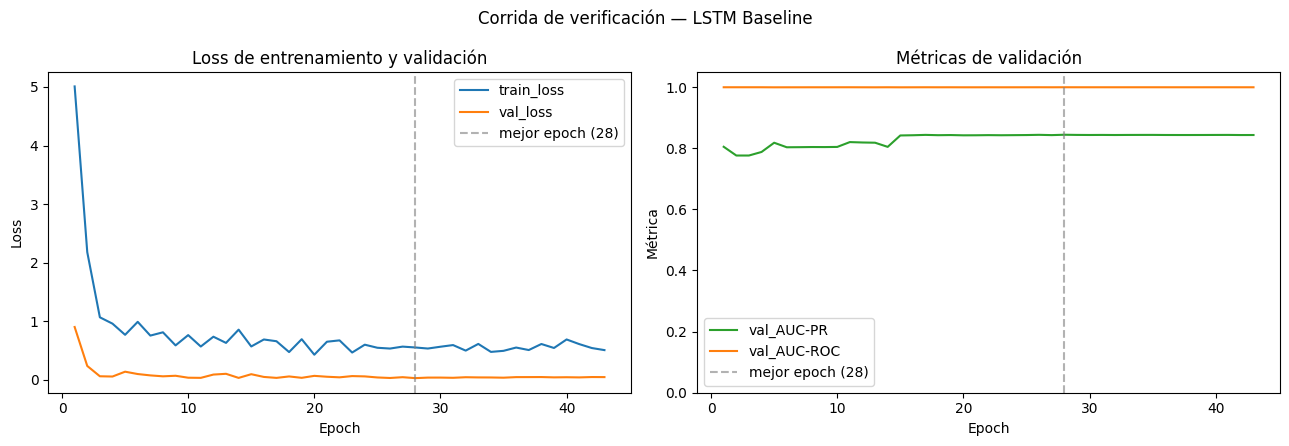

In [22]:
import importlib
import sys

if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import plot_training_history

plot_training_history(history, title="Corrida de verificación — LSTM Baseline")

El resultado es muy bueno y merece leerse con cuidado antes de seguir.
El modelo converge rapidamente y de forma estable. El mejor val_AUC-PR es 0.8441 en epoch 28, obtenido con una sola semilla, pw_factor=1.0 y max_epochs=100 como corrida de verificacion, no como entrenamiento final optimizado. Esto ya supera lo que el Baseline obtuvo en su corrida equivalente, aunque la comparacion definitiva debe hacerse sobre el ensamble de 3 semillas con el grid search completo, igual que se hizo en el Baseline.
Hay dos observaciones sobre el comportamiento del entrenamiento que conviene registrar.
La train_loss en epoch 1 es 5.009, lo cual es alto pero esperado: con pos_weight_raw bruto de 1967 sin atenuar (pw_factor=1.0 en esta corrida de verificacion), el gradiente de los positivos domina fuertemente al inicio. La caida rapida a partir del epoch 2 indica que el modelo encuentra rapidamente una region util del espacio de parametros.
El val_AUC-PR oscila entre 0.77 y 0.84 en los primeros epochs antes de estabilizarse. Eso es normal con solo 7 positivos en validacion: detectar 6 en vez de 7, o 7 en vez de 6, mueve la metrica de forma discreta y apreciable. No indica inestabilidad del modelo, es el mismo fenomeno documentado para el T-GCN con 2 positivos en val pero con mas margen aqui por tener 7.
El scheduler reduce el lr tres veces antes del early stopping, lo que indica que el modelo habia alcanzado un plateau real antes de parar. La meseta de AUC-PR entre epochs 26 y 43 con variacion menor a 0.001 confirma que la convergencia es genuina.
El siguiente paso es el grid search y el ensamble de 3 semillas, siguiendo el mismo protocolo que en el Baseline

In [ ]:
import gc
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import optuna
import torch

# 1. Asegurar entorno GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ejecutando Optuna en el dispositivo: {device} (Debe ser CUDA para T4)")

N_SEEDS = 3


def objective(trial: optuna.Trial) -> float:
    # Espacio de búsqueda sugerido
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    pw_factor = trial.suggest_float("pw_factor", 0.05, 1.0)

    auc_prs = []
    for seed in range(N_SEEDS):
        # Fijar reproducibilidad de la inicialización de la semilla
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        # Instanciar el modelo con Focal Bias Tuning integrado por defecto
        model = LSTMBaseline(
            d_in=192, lstm_hidden=32, dropout=dropout, num_layers=1
        )
        model = model.to(device)  # En GPU T4 esto será instantáneo

        # Ejecución del bucle de entrenamiento interno de tu módulo src.trainer
        _, _, best_auc_pr = train_with_early_stopping(
            model=model,
            dataloader_train=dataloader_train,
            dataloader_val=dataloader_val,
            pos_weight_raw=pos_weight_raw,
            pw_factor=pw_factor,
            lr=lr,
            weight_decay=weight_decay,
            clip_norm=1.0,
            max_epochs=100,
            patience=15,
            scheduler_factor=0.5,
            scheduler_patience=5,
            device=device,
            verbose=False,
        )
        auc_prs.append(best_auc_pr)

        # Limpieza quirúrgica de la VRAM de la GPU T4
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_auc_pr = float(np.mean(auc_prs))

    # Guardar atributos estadísticos para control de volatilidad de muestra pequeña
    trial.set_user_attr("auc_pr_per_seed", [float(x) for x in auc_prs])
    trial.set_user_attr("auc_pr_std", float(np.std(auc_prs)))

    return mean_auc_pr


# 2. Inicializar y correr el estudio bayesiano TPE
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

# 3. Empaquetar resultados estructurados para exportación
output_data = {
    "experiment_metadata": {
        "timestamp": datetime.now().isoformat(),
        "architecture": "LSTMBaseline",
        "n_trials": 15,
        "n_seeds_per_trial": N_SEEDS,
        "fixed_parameters": {"lstm_hidden": 32, "num_layers": 1},
    },
    "best_trial_summary": {
        "best_trial_id": study.best_trial.number,
        "best_mean_val_auc_pr": float(study.best_value),
        "best_params": study.best_params,
        "stability_metrics": {
            "auc_pr_per_seed": study.best_trial.user_attrs["auc_pr_per_seed"],
            "auc_pr_std": study.best_trial.user_attrs["auc_pr_std"],
        },
    },
    "all_trials_history": [
        {
            "trial_id": t.number,
            "mean_auc_pr": float(t.value) if t.value is not None else None,
            "params": t.params,
            "auc_pr_std": t.user_attrs.get("auc_pr_std", None),
            "state": str(t.state),
        }
        for t in study.trials
    ],
}

# 4. Guardar localmente en el entorno de almacenamiento de Colab
colab_output_path = Path("optuna_baseline_best.json")
with open(colab_output_path, "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=4, ensure_ascii=False)

print(
    f"\n[OK] Optimización terminada. Archivo guardado listo para descargar en Colab: {colab_output_path}"
)
